# Second model (goal=0.127992 (top 1000))

## ekual to model 1 (load train and head)

In [2]:
# Librerías para manipulación de datos y visualización
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Configuración para que se muestren bien los gráficos
%matplotlib inline
print("Librerías importadas correctamente.")




Librerías importadas correctamente.


In [46]:
 # Cargar los datos
df = pd.read_csv('../data/train.csv', index_col='Id')

# Mostrar las primeras 5 filas para confirmar la carga
print("Primeras 5 filas del dataset:")
df

Primeras 5 filas del dataset:


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500


## experiments

### First I make a correlation matrix similar to the one on EDA 2 (discarding 0's in some variables)

In [ ]:
#Numeric DataFrame
dfNum=df.select_dtypes(include=['float64', 'int64'])
#No numeric Variables
dfCat = df.select_dtypes(exclude=['float64', 'int64'])
Categorias=dfCat.columns.tolist()

# UnprecisecorrMatrix
corr_matrix = dfNum.corr()

dfNumClean=dfNum.copy()

columns_to_clean=['GarageArea', 'TotalBsmtSF', 'MasVnrArea', 'BsmtFinSF1', 'WoodDeckSF','2ndFlrSF', 'OpenPorchSF', 'BsmtUnfSF', 'EnclosedPorch','ScreenPorch','PoolArea','3SsnPorch','LowQualFinSF','MiscVal','BsmtFinSF2']
# I selected this features bc 0's in them mean lacking of the feature, 

#new corr
corr_matrix_2= dfNumClean.corr()['SalePrice'].drop('SalePrice')
new_corr= {}

#calc corr with saleprice for each feature independently (THIS ACTUUALLY IS NOT THAT USEFULL XD)
for column in columns_to_clean:
    new_corr[column]=dfNumClean[dfNumClean[column]!=0].corr()['SalePrice'][column]

#
dic_ordenado = dict(sorted(new_corr.items(), key=lambda x: x[1], reverse=True))

#substituing old with new correlations
for i in corr_matrix_2.index:
    if i in columns_to_clean:
        corr_matrix_2[i] = dic_ordenado[i]

#ordering
corr_matrix_2=corr_matrix_2.sort_values(ascending=False)
print(corr_matrix_2)
#THIS IS A MORE PRECIZE CORRELATION MATRIX


OverallQual      0.790982
GrLivArea        0.708624
2ndFlrSF         0.673305
GarageCars       0.640409
TotalBsmtSF      0.609681
GarageArea       0.608405
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
BsmtFinSF1       0.471690
Fireplaces       0.466929
MasVnrArea       0.434090
LotFrontage      0.351799
LowQualFinSF     0.300075
HalfBath         0.284108
LotArea          0.263843
ScreenPorch      0.255430
EnclosedPorch    0.241279
BsmtFullBath     0.227122
BsmtFinSF2       0.198956
WoodDeckSF       0.193706
BsmtUnfSF        0.169261
BedroomAbvGr     0.168213
MiscVal          0.088963
OpenPorchSF      0.086453
3SsnPorch        0.063932
MoSold           0.046432
PoolArea        -0.014092
BsmtHalfBath    -0.016844
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0,61,0,0,0,0,0,2,2008,208500
2,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,298,0,0,0,0,0,0,5,2007,181500
3,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,0,42,0,0,0,0,0,9,2008,223500
4,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,0,35,272,0,0,0,0,2,2006,140000
5,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,192,84,0,0,0,0,0,12,2008,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,62.0,7917,6,5,1999,2000,0.0,0,0,...,0,40,0,0,0,0,0,8,2007,175000
1457,20,85.0,13175,6,6,1978,1988,119.0,790,163,...,349,0,0,0,0,0,0,2,2010,210000
1458,70,66.0,9042,7,9,1941,2006,0.0,275,0,...,0,60,0,0,0,0,2500,5,2010,266500


### Import metrics to evaluate the model

In [5]:
forlinearfeatures=corr_matrix_2
n=25 #No, of variables to use

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [7]:
from sklearn.metrics import mean_squared_log_error

### A function to run the model many times, with different parameters (it has the same process as my model 1)

In [8]:
def idk(n1,forlinearfeatures,mod=False,rnd_ste=2):

    df_pred=df.copy()
    #N1 is the numbre of features to use counting from the most correleted to the least
    if n1>len(forlinearfeatures):
        #if n1 is greater than feats available, use available
        n1=len(forlinearfeatures)

    #forlinearfeaturues is the corr matrix
    for col in forlinearfeatures.index[:n1].tolist():
        df_pred[col]=df_pred[col].fillna(df_pred[col].median())
        #fill corr columns NaN with median 


    y=df_pred['SalePrice']

    df_pred_no_SP= df_pred[forlinearfeatures.index[:n1].tolist()].copy()

    for column in columns_to_clean:
        if column in df_pred_no_SP.columns:
            #for each column to clean if is in the df, create a has feature with 0 if 0 and 1 if >0
            df_pred_no_SP[f'has {column}']=(df_pred_no_SP[column]>0).astype(int)
            df_pred_no_SP


    final_df_for_reg=df_pred_no_SP.copy()
    x_train, x_test, y_train, y_test = train_test_split(final_df_for_reg,y, test_size=0.2, random_state=rnd_ste)


    reg=LinearRegression()
    reg.fit(x_train,y_train)
    y_hat=reg.predict(x_test)

    mae = mean_absolute_error(y_test, y_hat)
    mse = mean_squared_error(y_test, y_hat)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_hat)

    
    # scores=pd.DataFrame(data={'Medida':["MAE","MSE","RMSE","R2"],'Valor':[mae,mse,rmse,r2]})
    # scores.style.format({'Valor': '{:.2f}'})

    #get rid of 0's for RMSLE
    y_pred_no0 = np.maximum(y_hat, 0)
    y_test_no0 = np.maximum(y_test, 0)

    rmsle = np.sqrt(mean_squared_log_error(y_test_no0, y_pred_no0))

    #mod is for returning the model intead of metrics
    if mod:
        return reg

    return {n1:[mae,mse,rmse,r2,rmsle]}


### analysis

calculate the model for every n (from 1 to 36 variables) and get metrics on a list

In [9]:
metrics=[]
for n1 in range(1,37):
    metrics.append(idk(n1,corr_matrix_2))



display log error, for every n and plot it, also calculate the change in the error when we move from one variable to the next, and finally display the n's (features that caused the error to raise)

for n=1, Logerror= 0.2624555525540694
for n=2, Logerror= 0.21058472091639807
for n=3, Logerror= 0.19801884426910063
for n=4, Logerror= 0.19282513647028598
for n=5, Logerror= 0.17526448042873494
for n=6, Logerror= 0.171772233257099
for n=7, Logerror= 0.17228251441046746
for n=8, Logerror= 0.1722793514519372
for n=9, Logerror= 0.17219159626561575
for n=10, Logerror= 0.17310683643484157
for n=11, Logerror= 0.17032487786919767
for n=12, Logerror= 0.17455531011806452
for n=13, Logerror= 0.1727391701738103
for n=14, Logerror= 0.17146099028658046
for n=15, Logerror= 0.17118008335375198
for n=16, Logerror= 0.17129101927338478
for n=17, Logerror= 0.17114218154470218
for n=18, Logerror= 0.17117910012153287
for n=19, Logerror= 0.1699753650171235
for n=20, Logerror= 0.17081693482724225
for n=21, Logerror= 0.17088737377805724
for n=22, Logerror= 0.1711894462572046
for n=23, Logerror= 0.17056212631472487
for n=24, Logerror= 0.16890206876882044
for n=25, Logerror= 0.16853970070145308
for n=26, Logerr

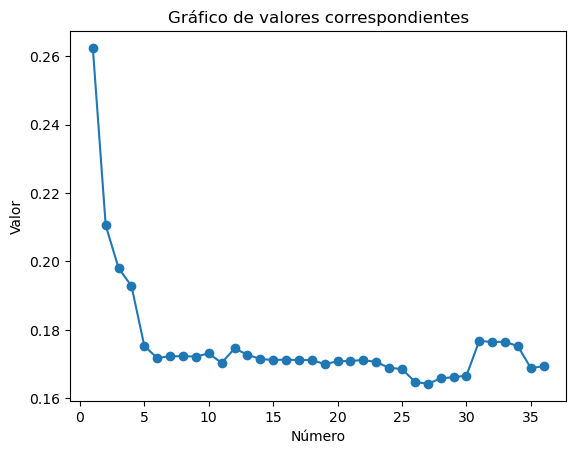

for n=2 change was 0.05187083163767131
for n=3 change was 0.012565876647297441
for n=4 change was 0.005193707798814645
for n=5 change was 0.017560656041551048
for n=6 change was 0.0034922471716359316
for n=7 change was -0.0005102811533684581
for n=8 change was 3.162958530256166e-06
for n=9 change was 8.775518632145318e-05
for n=10 change was -0.0009152401692258116
for n=11 change was 0.002781958565643894
for n=12 change was -0.00423043224886685
for n=13 change was 0.0018161399442542248
for n=14 change was 0.0012781798872298356
for n=15 change was 0.00028090693282847856
for n=16 change was -0.00011093591963279303
for n=17 change was 0.00014883772868259926
for n=18 change was -3.691857683069122e-05
for n=19 change was 0.0012037351044093814
for n=20 change was -0.0008415698101187641
for n=21 change was -7.04389508149883e-05
for n=22 change was -0.000302072479147375
for n=23 change was 0.0006273199424797482
for n=24 change was 0.0016600575459044253
for n=25 change was 0.0003623680673673635

{7: np.float64(-0.0005102811533684581),
 10: np.float64(-0.0009152401692258116),
 12: np.float64(-0.00423043224886685),
 16: np.float64(-0.00011093591963279303),
 18: np.float64(-3.691857683069122e-05),
 20: np.float64(-0.0008415698101187641),
 21: np.float64(-7.04389508149883e-05),
 22: np.float64(-0.000302072479147375),
 28: np.float64(-0.001624922033745979),
 29: np.float64(-0.0003582177902141104),
 30: np.float64(-0.00043435946794787017),
 31: np.float64(-0.01022523942941983),
 33: np.float64(-0.00015123929748755982),
 36: np.float64(-0.0005422805568775502)}

In [10]:

for i in metrics:
    i:dict
    print(f"for n={list(i.keys())[0]}, Logerror= {list(i.values())[0][-1]}")
ns= list(range(1, 37))
rmsles = [list(i.values())[0][-1] for i in metrics]
plt.plot(ns, rmsles, marker='o')
plt.xlabel('Número')
plt.ylabel('Valor')
plt.title('Gráfico de valores correspondientes')
plt.show()
moves={}
for i in ns:
    i2=i-1

    if i==ns[-1]:
        break
    cambio=rmsles[i2]-rmsles[i]
    print(f'for n={i+1} change was {cambio}')
    if cambio<0:
        moves[i+1]=cambio
moves

now we select form corr matrix, the features that increased our error

In [11]:

corrinlist=corr_matrix_2.index.to_list()
corrmatrix3=corr_matrix_2.copy()

negativefeats=[]
for i in moves.keys():
    negativefeats.append(corrinlist[i-1])

    corrmatrix3=corrmatrix3.drop(corrinlist[i-1])

print("from de corr matrix we took", negativefeats)
corrmatrix3



from de corr matrix we took ['1stFlrSF', 'YearBuilt', 'GarageYrBlt', 'LotFrontage', 'HalfBath', 'ScreenPorch', 'EnclosedPorch', 'BsmtFullBath', 'OpenPorchSF', '3SsnPorch', 'MoSold', 'PoolArea', 'YrSold', 'KitchenAbvGr']


OverallQual     0.790982
GrLivArea       0.708624
2ndFlrSF        0.673305
GarageCars      0.640409
TotalBsmtSF     0.609681
GarageArea      0.608405
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearRemodAdd    0.507101
BsmtFinSF1      0.471690
Fireplaces      0.466929
MasVnrArea      0.434090
LowQualFinSF    0.300075
LotArea         0.263843
BsmtFinSF2      0.198956
WoodDeckSF      0.193706
BsmtUnfSF       0.169261
BedroomAbvGr    0.168213
MiscVal         0.088963
BsmtHalfBath   -0.016844
OverallCond    -0.077856
MSSubClass     -0.084284
Name: SalePrice, dtype: float64

Now we train the model again using the new feats, and do the same thing as before

In [12]:
metrics=[]
for n1 in range(1,37):
    metrics.append(idk(n1,corrmatrix3))

for n=1, Logerror= 0.2624555525540694
for n=2, Logerror= 0.21058472091639807
for n=3, Logerror= 0.19801884426910063
for n=4, Logerror= 0.19282513647028598
for n=5, Logerror= 0.17526448042873494
for n=6, Logerror= 0.171772233257099
for n=7, Logerror= 0.1718014360612155
for n=8, Logerror= 0.1716490483621078
for n=9, Logerror= 0.1679865382059482
for n=10, Logerror= 0.1673386174189187
for n=11, Logerror= 0.16733160082497034
for n=12, Logerror= 0.1679185682792388
for n=13, Logerror= 0.1679490619363167
for n=14, Logerror= 0.16715755410613276
for n=15, Logerror= 0.16665306310236205
for n=16, Logerror= 0.1644765997422001
for n=17, Logerror= 0.1643108148147912
for n=18, Logerror= 0.16218098241805756
for n=19, Logerror= 0.16163820893587055
for n=20, Logerror= 0.16172001399270974
for n=21, Logerror= 0.15905712746620776
for n=22, Logerror= 0.15849173904379354
for n=22, Logerror= 0.15849173904379354
for n=22, Logerror= 0.15849173904379354
for n=22, Logerror= 0.15849173904379354
for n=22, Logerror= 

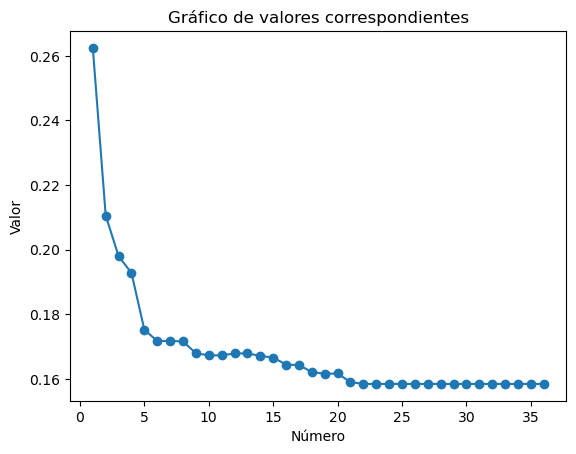

para n=2 el cambio fue 0.05187083163767131
para n=3 el cambio fue 0.012565876647297441
para n=4 el cambio fue 0.005193707798814645
para n=5 el cambio fue 0.017560656041551048
para n=6 el cambio fue 0.0034922471716359316
para n=7 el cambio fue -2.9202804116501557e-05
para n=8 el cambio fue 0.00015238769910772
para n=9 el cambio fue 0.003662510156159593
para n=10 el cambio fue 0.0006479207870294934
para n=11 el cambio fue 7.016593948361294e-06
para n=12 el cambio fue -0.00058696745426845
para n=13 el cambio fue -3.0493657077912406e-05
para n=14 el cambio fue 0.0007915078301839462
para n=15 el cambio fue 0.0005044910037707018
para n=16 el cambio fue 0.0021764633601619454
para n=17 el cambio fue 0.00016578492740890183
para n=18 el cambio fue 0.002129832396733644
para n=19 el cambio fue 0.0005427734821870089
para n=20 el cambio fue -8.180505683919037e-05
para n=21 el cambio fue 0.002662886526501984
para n=22 el cambio fue 0.0005653884224142147
para n=23 el cambio fue 0.0
para n=24 el cambio

{7: np.float64(-2.9202804116501557e-05),
 12: np.float64(-0.00058696745426845),
 13: np.float64(-3.0493657077912406e-05),
 20: np.float64(-8.180505683919037e-05)}

In [13]:
for i in metrics:
    i:dict
    print(f"for n={list(i.keys())[0]}, Logerror= {list(i.values())[0][-1]}")
ns= list(range(1, 37))
rmsles = [list(i.values())[0][-1] for i in metrics]
plt.plot(ns, rmsles, marker='o')
plt.xlabel('Número')
plt.ylabel('Valor')
plt.title('Gráfico de valores correspondientes')
plt.show()
moves={}
for i in ns:
    i2=i-1

    if i==ns[-1]:
        break
    cambio=rmsles[i2]-rmsles[i]
    print(f'para n={i+1} el cambio fue {cambio}')
    if cambio<0:
        moves[i+1]=cambio
moves

new negative variables now are very small, im not discarding them

and now i train the model and predcit the submission file

In [ ]:
model=idk(90,corrmatrix3,mod=True)
import joblib
joblib.dump(model, 'Model_1_3.joblib')
df_test = pd.read_csv('../data/test.csv', index_col='Id')

In [44]:
idk(90,corrmatrix3)

{22: [21078.217416247644,
  951616371.8990456,
  np.float64(30848.27988557945),
  0.856300476815983,
  np.float64(0.15849173904379354)]}

In [15]:
x_test_test= df_test[corrmatrix3.index[:n].tolist()].copy()
x_test_test=x_test_test.fillna(x_test_test.median())
for column in columns_to_clean:
    if column in x_test_test.columns:
        x_test_test[f'has {column}']=(x_test_test[column]>0).astype(int)

In [16]:
pred_test=model.predict(x_test_test)

In [17]:
submission = pd.DataFrame({
    'Id': x_test_test.index,
    'SalePrice': pred_test
})

# Guardar el archivo
submission.to_csv('submission_1_2.csv', index=False)
print("Archivo de submission creado exitosamente!")

Archivo de submission creado exitosamente!


This model got .19117

but this was only tested on random state 2, i'will make a function that makes this hole process, for 300 random states, and i will analyze what ia got from that

In [18]:

def new_model_func(n1,forlinearfeatures,mod=False,rnd_ste=2):

    df_pred=df.copy()
    #N1 is the numbre of features to use counting from the most correleted to the least
    if n1>len(forlinearfeatures):
        #if n1 is greater than feats available, use available
        n1=len(forlinearfeatures)

    #forlinearfeaturues is the corr matrix
    for col in forlinearfeatures.index[:n1].tolist():
        df_pred[col]=df_pred[col].fillna(df_pred[col].median())
        #fill corr columns NaN with median 


    y=df_pred['SalePrice']

    df_pred_no_SP= df_pred[forlinearfeatures.index[:n1].tolist()].copy()

    for column in columns_to_clean:
        if column in df_pred_no_SP.columns:
            #for each column to clean if is in the df, create a has feature with 0 if 0 and 1 if >0
            df_pred_no_SP[f'has {column}']=(df_pred_no_SP[column]>0).astype(int)
            df_pred_no_SP


    final_df_for_reg=df_pred_no_SP.copy()
    x_train, x_test, y_train, y_test = train_test_split(final_df_for_reg,y, test_size=0.2, random_state=rnd_ste)


    reg=LinearRegression()
    reg.fit(x_train,y_train)
    y_hat=reg.predict(x_test)
    
    # scores=pd.DataFrame(data={'Medida':["MAE","MSE","RMSE","R2"],'Valor':[mae,mse,rmse,r2]})
    # scores.style.format({'Valor': '{:.2f}'})

    #get rid of 0's for RMSLE
    y_pred_no0 = np.maximum(y_hat, 0)
    y_test_no0 = np.maximum(y_test, 0)

    rmsle = np.sqrt(mean_squared_log_error(y_test_no0, y_pred_no0))
    #mod is for returning the model intead of metrics
    if mod:
        return reg

    return rmsle


In [19]:
all_runs=[]
all_moves=[]
all_best=[]
all_best_names=[]
all_best_numb=[]
corrinlist=corr_matrix_2.index.to_list()
tries=300

for rnd_state in range(1,tries+1):
    
    rnd_state_rns=[0]
    moves_run=[]
    negativefeats=[]
    negativefeats_no=[]
    i=0
    for ns_in_run in range(1,37):
        rmsle_of_run=new_model_func(ns_in_run,corr_matrix_2,rnd_ste=rnd_state)
        move=rnd_state_rns[-1]-rmsle_of_run
        moves_run.append(move)
        if move<0:
            negativefeats.append(corrinlist[i])
            negativefeats_no.append(i)
        rnd_state_rns.append(rmsle_of_run)
        i+=1

    rnd_state_rns=rnd_state_rns[1:]
    moves_run=moves_run[1:]
    negativefeats=negativefeats[1:]
    negativefeats_no=negativefeats_no[1:]
    
    all_runs.append(rnd_state_rns)
    all_moves.append(moves_run)
    
    corrmatrix_cleaned=corr_matrix_2.drop(negativefeats)
    best=new_model_func(37,corrmatrix_cleaned,rnd_ste=rnd_state)
    all_best.append(best)
    all_best_names.append(negativefeats)
    all_best_numb.append(negativefeats_no)

In [20]:
rands= list(range(1,tries+1))

In [21]:
titles=[]
n=list(range(1,37))
for i in n:
    titles.append(f'N={i}')

In [22]:
df_metrics=pd.DataFrame(all_runs,columns=titles,index=rands)
df_metrics

,N=1,N=2,N=3,N=4,N=5,N=6,N=7,N=8,N=9,N=10,...,N=27,N=28,N=29,N=30,N=31,N=32,N=33,N=34,N=35,N=36
1,0.945887,0.688756,0.680770,0.689694,0.934245,0.269117,0.249451,0.251912,0.262952,0.223803,...,0.194242,0.196042,0.196105,0.196414,0.201112,0.201171,0.203454,0.675804,0.242443,0.212770
2,0.262456,0.210585,0.198019,0.192825,0.175264,0.171772,0.172283,0.172279,0.172192,0.173107,...,0.164183,0.165808,0.166166,0.166601,0.176826,0.176399,0.176551,0.175185,0.168818,0.169360
3,0.230555,0.219532,0.210338,0.205946,0.204742,0.201847,0.199614,0.200253,0.199495,0.194965,...,0.186608,0.188626,0.188122,0.188353,0.188172,0.188102,0.189280,0.189873,0.185579,0.185821
4,0.692577,0.678069,0.670580,0.670769,0.668644,0.245818,0.219582,0.218573,0.226528,0.194905,...,0.179317,0.179645,0.179886,0.180011,0.180652,0.180649,0.180378,0.665234,0.207036,0.189258
5,0.926598,0.663970,0.652865,0.664822,0.912019,0.651000,0.649077,0.649069,0.649381,0.645827,...,0.645049,0.645061,0.645010,0.645147,0.644393,0.644457,0.644451,0.647716,0.643853,0.276931
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,0.687553,0.236029,0.192709,0.220919,0.668432,0.194170,0.182964,0.183561,0.182349,0.177543,...,0.166439,0.166423,0.166492,0.166802,0.171535,0.172368,0.175918,0.194937,0.167435,0.165096
297,0.694305,0.681202,0.676021,0.673927,0.671836,0.219219,0.210061,0.215252,0.210269,0.192679,...,0.186992,0.187962,0.189944,0.190132,0.184848,0.184692,0.184545,0.283805,0.198410,0.182215
298,0.932011,0.679174,0.659465,0.671173,0.917418,0.659034,0.654220,0.654746,0.653668,0.650933,...,0.644360,0.644405,0.644187,0.644264,0.645883,0.645864,0.645951,0.650450,0.644866,0.643613
299,1.135118,0.933249,0.924530,0.929943,0.952777,0.685590,0.673408,0.670323,0.668007,0.662212,...,0.654581,0.654764,0.654943,0.655105,0.654606,0.654499,0.654804,0.925321,0.665024,0.657551


In [23]:
df_moves=pd.DataFrame(all_moves,columns=titles[1:],index=rands)

df_moves

,N=2,N=3,N=4,N=5,N=6,N=7,N=8,N=9,N=10,N=11,...,N=27,N=28,N=29,N=30,N=31,N=32,N=33,N=34,N=35,N=36
1,0.257132,0.007986,-0.008924,-0.244552,0.665128,0.019666,-0.002461,-0.011039,0.039148,-0.003788,...,0.001181,-0.001799,-0.000064,-0.000309,-0.004698,-0.000059,-0.002283,-0.472349,0.433360,0.029674
2,0.051871,0.012566,0.005194,0.017561,0.003492,-0.000510,0.000003,0.000088,-0.000915,0.002782,...,0.000617,-0.001625,-0.000358,-0.000434,-0.010225,0.000426,-0.000151,0.001365,0.006368,-0.000542
3,0.011024,0.009194,0.004392,0.001204,0.002895,0.002233,-0.000638,0.000758,0.004530,0.004984,...,0.000327,-0.002018,0.000503,-0.000230,0.000181,0.000069,-0.001178,-0.000593,0.004295,-0.000242
4,0.014508,0.007489,-0.000189,0.002124,0.422826,0.026236,0.001009,-0.007955,0.031623,-0.000897,...,0.000700,-0.000329,-0.000241,-0.000124,-0.000641,0.000002,0.000272,-0.484856,0.458197,0.017778
5,0.262628,0.011106,-0.011957,-0.247197,0.261019,0.001923,0.000008,-0.000312,0.003554,-0.000864,...,-0.000563,-0.000013,0.000052,-0.000137,0.000753,-0.000064,0.000006,-0.003265,0.003863,0.366921
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,0.451524,0.043320,-0.028210,-0.447513,0.474262,0.011207,-0.000597,0.001211,0.004807,-0.001225,...,-0.000546,0.000016,-0.000069,-0.000311,-0.004733,-0.000833,-0.003550,-0.019019,0.027502,0.002339
297,0.013103,0.005181,0.002094,0.002090,0.452618,0.009158,-0.005192,0.004984,0.017590,0.001138,...,-0.001231,-0.000971,-0.001981,-0.000188,0.005283,0.000156,0.000147,-0.099260,0.085395,0.016195
298,0.252837,0.019709,-0.011708,-0.246245,0.258384,0.004815,-0.000526,0.001078,0.002735,-0.000818,...,-0.000683,-0.000045,0.000218,-0.000077,-0.001619,0.000019,-0.000087,-0.004499,0.005584,0.001253
299,0.201869,0.008719,-0.005413,-0.022834,0.267186,0.012182,0.003085,0.002316,0.005795,0.000155,...,0.000561,-0.000183,-0.000180,-0.000161,0.000499,0.000107,-0.000305,-0.270518,0.260297,0.007473


In [24]:
df_best=pd.DataFrame(all_best,columns=["Best"],index=rands)
df_best


,Best
1,0.177890
2,0.158492
3,0.179303
4,0.161513
5,0.642383
...,...
296,0.161986
297,0.158673
298,0.642649
299,0.646955


In [25]:
idx_best=df_best['Best'].idxmin()
bestnnames=all_best_names[idx_best-1]
best=df_best['Best'].min()
print(f'the best prediction was: {best} excluding: {bestnnames}')

the best prediction was: 0.12879348777098318 excluding: ['GarageCars', 'FullBath', 'TotRmsAbvGrd', 'GarageYrBlt', 'LotFrontage', 'HalfBath', 'LotArea', 'ScreenPorch', 'EnclosedPorch', 'WoodDeckSF', 'MiscVal', 'OpenPorchSF', '3SsnPorch', 'MoSold', 'BsmtHalfBath', 'YrSold']


In [26]:
df_best=pd.DataFrame(all_best_numb,index=rands)
df_best

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
1,3,4,7,8,10,11,12.0,15.0,19.0,20.0,...,27.0,28.0,29.0,30.0,31.0,32.0,33.0,NaN,NaN,NaN
2,6,9,11,15,17,19,20.0,21.0,27.0,28.0,...,30.0,32.0,35.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,7,13,15,16,17,22,25.0,27.0,29.0,32.0,...,35.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3,8,10,11,12,14,16.0,19.0,20.0,23.0,...,28.0,29.0,30.0,33.0,NaN,NaN,NaN,NaN,NaN,NaN
5,3,4,8,10,11,12,15.0,17.0,18.0,19.0,...,21.0,23.0,26.0,27.0,29.0,31.0,33.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,3,4,7,10,11,12,15.0,17.0,18.0,20.0,...,23.0,26.0,28.0,29.0,30.0,31.0,32.0,33.0,NaN,NaN
297,7,11,14,16,17,19,20.0,23.0,26.0,27.0,...,29.0,33.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
298,3,4,7,10,11,12,16.0,17.0,18.0,20.0,...,23.0,26.0,27.0,29.0,30.0,32.0,33.0,NaN,NaN,NaN
299,3,4,11,12,15,18,20.0,23.0,27.0,28.0,...,32.0,33.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
vars=corr_matrix_2.drop(bestnnames)

model=new_model_func(90,vars,mod=True,rnd_ste=idx_best)
import joblib
joblib.dump(model, 'Model_1_4.joblib')
df_test = pd.read_csv('../data/test.csv', index_col='Id')

x_test_test= df_test[vars.index.tolist()].copy()
x_test_test=x_test_test.fillna(x_test_test.median())
for column in columns_to_clean:
    if column in x_test_test.columns:
        x_test_test[f'has {column}']=(x_test_test[column]>0).astype(int)

pred_test=model.predict(x_test_test)
submission = pd.DataFrame({
    'Id': x_test_test.index,
    'SalePrice': pred_test
})

# Guardar el archivo
submission.to_csv('submission_1_4.csv', index=False)
print("Archivo de submission creado exitosamente!")

Archivo de submission creado exitosamente!


In [28]:
new_model_func(90,vars,rnd_ste=idx_best)

np.float64(0.12879348777098318)

So this got .69 on kaggle, so this probably is overfitting, im gonna evaluate this model on many different test splits

In [29]:
triesforbest=[]
for rdm in range(1,500):
    triesforbest.append(new_model_func(90,vars,rnd_ste=rdm))


In [30]:
tiresforbestdf=pd.DataFrame(triesforbest,columns=["tries"])

In [31]:
print(tiresforbestdf["tries"].mean(),tiresforbestdf["tries"].max(),tiresforbestdf["tries"].min())

0.30016384429092086 1.0577744353082397 0.12879348777098318


In [32]:
df_moves.columns=list(range(1,36))


In [33]:
nonimportantfeats=df_moves

nonimportantfeats=nonimportantfeats.max().sort_values(ascending=False).index.to_list()
nonimportantfeats=nonimportantfeats[-1:23:-1]

# nonimportantfeats=nonimportantfeats.loc[:nonimportantfeats.mean()>0]

In [34]:
corr_matrix_4=corr_matrix_2
for i in nonimportantfeats:
    
    corr_matrix_4=corr_matrix_4.drop(corr_matrix_2.index[i])



In [35]:
corr_matrix_4

OverallQual     0.790982
GrLivArea       0.708624
2ndFlrSF        0.673305
GarageCars      0.640409
TotalBsmtSF     0.609681
GarageArea      0.608405
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
GarageYrBlt     0.486362
BsmtFinSF1      0.471690
Fireplaces      0.466929
MasVnrArea      0.434090
HalfBath        0.284108
LotArea         0.263843
BsmtFullBath    0.227122
BsmtFinSF2      0.198956
BsmtUnfSF       0.169261
BedroomAbvGr    0.168213
MiscVal         0.088963
MoSold          0.046432
PoolArea       -0.014092
MSSubClass     -0.084284
KitchenAbvGr   -0.135907
Name: SalePrice, dtype: float64

In [36]:
triesforselectedfeatures=[]
for rdm in range(1,500):
    triesforselectedfeatures.append(new_model_func(90,corr_matrix_4,rnd_ste=rdm))


In [37]:
bestdfv3=pd.DataFrame(triesforselectedfeatures)
bestindx2=bestdfv3[0].idxmin()+1
bestdfv3.min()

0    0.136781
dtype: float64

In [38]:
new_model_func(90,corr_matrix_4,rnd_ste=bestindx2)

np.float64(0.13678061795956212)

In [39]:
def createsubmissionfie(name,corrmatrx,rnd=2):

    model=new_model_func(90,corrmatrx,mod=True,rnd_ste=rnd)
    import joblib
    joblib.dump(model, f'Model_{name}.joblib')
    df_test = pd.read_csv('../data/test.csv', index_col='Id')

    x_test_test= df_test[corrmatrx.index.tolist()].copy()
    x_test_test=x_test_test.fillna(x_test_test.median())
    for column in columns_to_clean:
        if column in x_test_test.columns:
            x_test_test[f'has {column}']=(x_test_test[column]>0).astype(int)

    pred_test=model.predict(x_test_test)
    submission = pd.DataFrame({
        'Id': x_test_test.index,
        'SalePrice': pred_test
    })

    # Guardar el archivo
    submission.to_csv(f'Submission_{name}.csv', index=False)
    print("Archivo de submission creado exitosamente!")

In [40]:
createsubmissionfie("1_7",corr_matrix_4,idx_best)

Archivo de submission creado exitosamente!


In [41]:
corrmatrix3 #fetures that gave best score

OverallQual     0.790982
GrLivArea       0.708624
2ndFlrSF        0.673305
GarageCars      0.640409
TotalBsmtSF     0.609681
GarageArea      0.608405
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearRemodAdd    0.507101
BsmtFinSF1      0.471690
Fireplaces      0.466929
MasVnrArea      0.434090
LowQualFinSF    0.300075
LotArea         0.263843
BsmtFinSF2      0.198956
WoodDeckSF      0.193706
BsmtUnfSF       0.169261
BedroomAbvGr    0.168213
MiscVal         0.088963
BsmtHalfBath   -0.016844
OverallCond    -0.077856
MSSubClass     -0.084284
Name: SalePrice, dtype: float64

In [42]:
triesforbest2=[]
for rdm in range(1,500):
    triesforbest2.append(new_model_func(90,corrmatrix3,rnd_ste=rdm))


In [43]:
idx_lastry=pd.DataFrame(triesforbest2)[0].idxmin()
print(new_model_func(90,corrmatrix3,rnd_ste=idx_lastry))
createsubmissionfie("1_8",corrmatrix3,idx_lastry)

0.643271932645056
Archivo de submission creado exitosamente!
